# Meta-Learners

En este capítulo exploraremos los meta-learners, una familia de métodos que permiten estimar efectos causales heterogéneos (CATE) utilizando algoritmos de machine learning convencionales. El objetivo principal será entender cómo diferentes unidades responden de manera distinta al tratamiento, lo que resulta esencial cuando no podemos tratar a todos y debemos priorizar, como en campañas de descuentos con presupuesto limitado.

Primero, repasaremos la motivación detrás de la estimación de efectos heterogéneos y su importancia práctica. Luego, veremos cómo los meta-learners (como el S-learner, T-learner y X-learner) reutilizan modelos predictivos para inferencia causal, permitiendo abordar datos de alta dimensión y relaciones complejas.

Finalmente, aprenderemos a implementar estos métodos en Python, discutiendo sus ventajas, limitaciones y cómo elegir el algoritmo de machine learning más adecuado para cada caso.


In [1]:
import polars as pl
import numpy as np
from plotnine import *

from fklearn.causal.validation.curves import relative_cumulative_gain_curve
from fklearn.causal.validation.auc import area_under_the_relative_cumulative_gain_curve

## Metalearners for Discrete Treatment

In [2]:
data_biased = pl.read_csv("../data/email_obs_data.csv")
data_rnd = pl.read_csv("../data/email_rnd_data.csv")

print(len(data_biased), len(data_rnd))
data_rnd.head()

300000 10000


mkt_email,next_mnth_pv,age,tenure,ammount_spent,vehicle,food,beverage,art,baby,personal_care,toys,clothing,decor,cell_phones,construction,home_appliances,electronics,sports,tools,games,industry,pc,jewel,books,music_books_movies,health
i64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,244.26,61.0,1.0,21.84,0,2,2,0,2,0,0,2,0,3,1,1,1,0,0,3,1,0,1,0,0,2
0,29.67,36.0,1.0,107.4,0,2,0,2,0,0,1,2,2,3,1,1,1,1,1,2,1,2,1,0,2,2
0,11.73,64.0,0.0,59.81,0,1,0,0,0,3,1,3,0,2,1,1,2,0,0,3,0,1,0,1,0,1
0,41.41,74.0,0.0,62.98,0,1,0,0,3,1,0,0,2,6,3,1,1,0,2,2,1,1,0,4,1,0
0,447.89,59.0,0.0,72.56,0,1,1,3,2,2,2,3,0,2,0,1,5,0,0,1,0,0,1,1,2,1


In [3]:
y = "next_mnth_pv"
T = "mkt_email"
X = list(data_rnd.drop([y, T]).columns)

## T-Learner

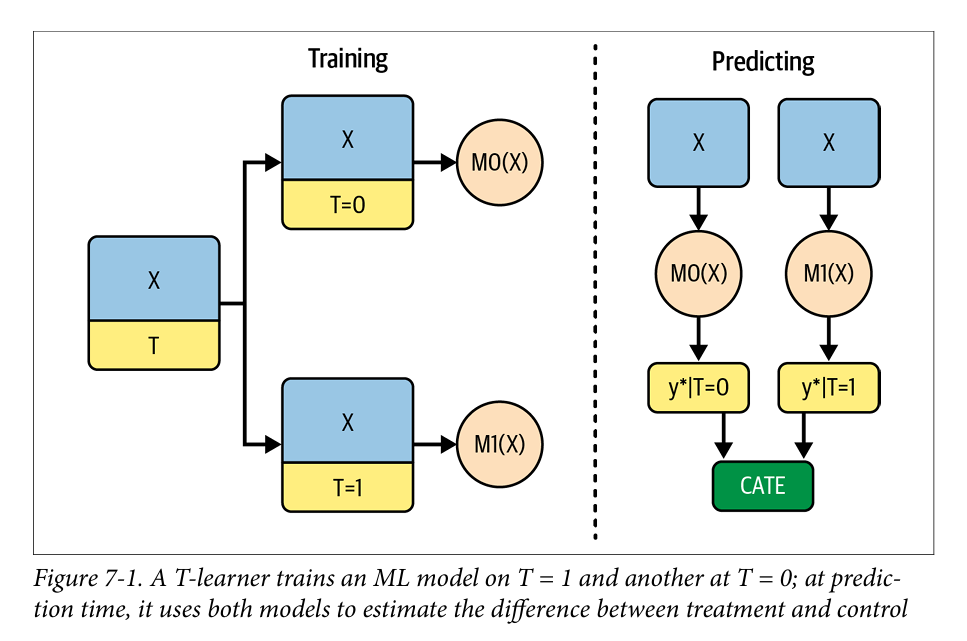

In [4]:
train, test = data_biased, data_rnd

In [5]:
from lightgbm import LGBMRegressor

np.random.seed(123)

m0 = LGBMRegressor()
m1 = LGBMRegressor()

m0.fit(train.filter(pl.col(T)==0).select(X).to_numpy(), 
       train.filter(pl.col(T)==0)
            .select(y).to_numpy().ravel())
m1.fit(train.filter(pl.col(T)==1).select(X).to_numpy(), 
       train.filter(pl.col(T)==1)
            .select(y).to_numpy().ravel())


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 146759, number of used features: 25
[LightGBM] [Info] Start training from score 88.249324
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004942 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 153241, number of used features: 25
[LightGBM] [Info] Start training from score 1596.224063


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [6]:
t_learner_cate_test = test.with_columns(
    cate=pl.Series(m1.predict(test.select(X).to_numpy()) - 
                   m0.predict(test.select(X).to_numpy())
                )
)

C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names


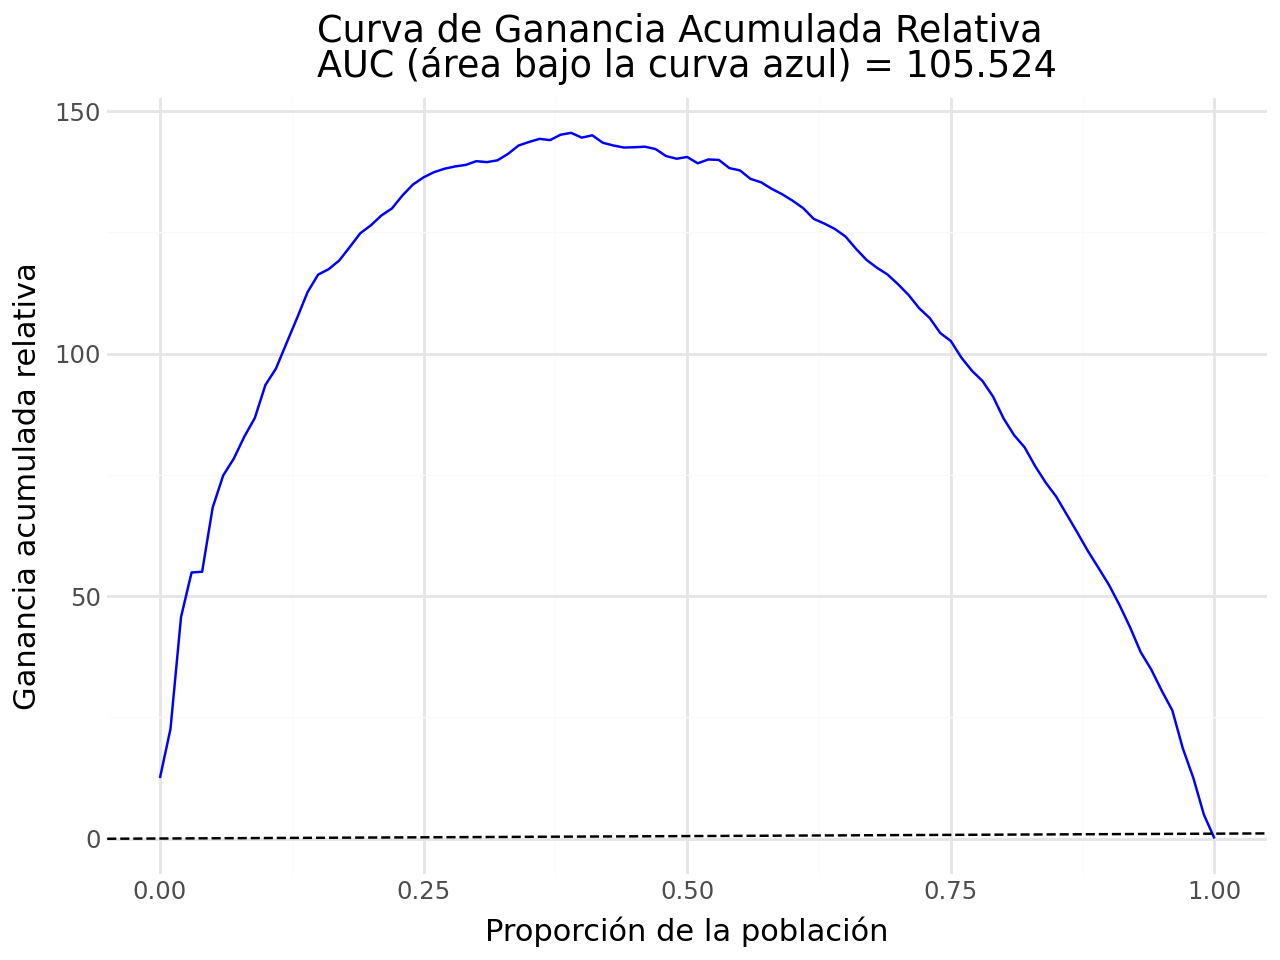

In [7]:
gain_curve_test = relative_cumulative_gain_curve(t_learner_cate_test.to_pandas(), T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(t_learner_cate_test.to_pandas(), T, y, prediction="cate")
gain_curve_test = pl.DataFrame(gain_curve_test, schema=["gain"])
x = np.linspace(0, 1, len(gain_curve_test))

# La curva azul representa el "Relative Cumulative Gain Curve", cuyo área bajo la curva (AUC) es nuestro estimador de performance causal. La línea punteada es el baseline (lo que esperaríamos si el modelo no tuviera poder predictivo causal).
# Nota: El valor de AUC está incluido en el título para facilitar la interpretación.

(
    ggplot(gain_curve_test) +
    geom_line(aes(x=x, y="gain"), color="blue") +  # Línea azul: curva de ganancia acumulada (AUC)
    geom_abline(slope=1, intercept=0, linetype="dashed") +  # Línea punteada: baseline (modelo aleatorio)
    labs(
        title=f"Curva de Ganancia Acumulada Relativa\nAUC (área bajo la curva azul) = {auc:.3f}",
        x="Proporción de la población",
        y="Ganancia acumulada relativa"
    ) +
    theme_minimal()
)

C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names


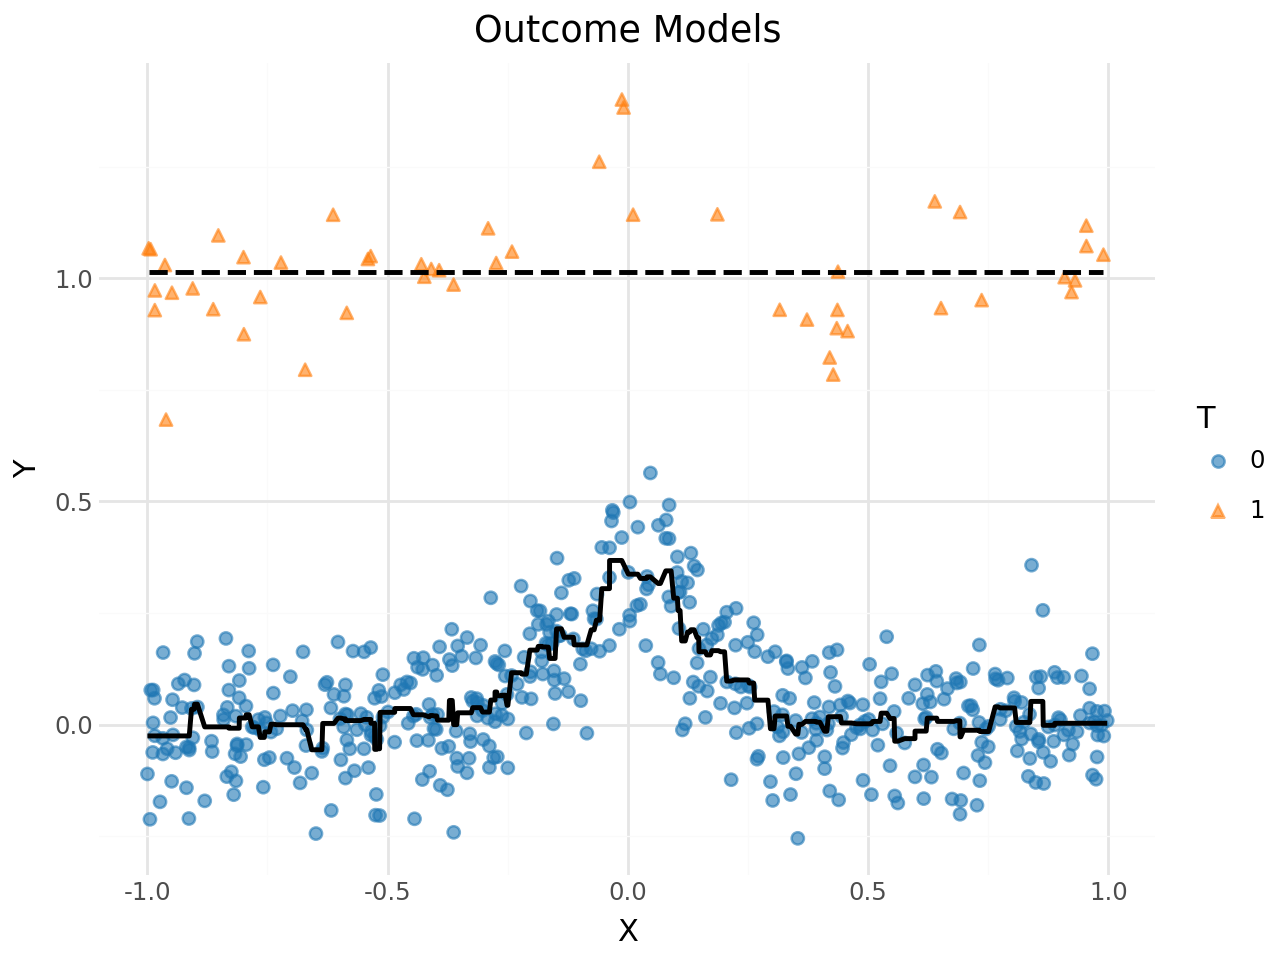

In [8]:
import numpy as np
import polars as pl
from lightgbm import LGBMRegressor
from plotnine import *

# Configuración de semilla
np.random.seed(123)

# Definición del Kernel
def g_kernel(x, c=0, s=0.05): 
    return np.exp((-(x-c)**2)/s)

# Generación de datos (T=0)
n0 = 500
x0 = np.random.uniform(-1, 1, n0)
y0 = np.random.normal(0.3*g_kernel(x0), 0.1, n0)

# Generación de datos (T=1)
n1 = 50
x1 = np.random.uniform(-1, 1, n1)
y1 = np.random.normal(0.3*g_kernel(x1), 0.1, n1) + 1

# Creación del DataFrame con Polars
df = pl.concat([
    pl.DataFrame({"x": x0, "y": y0, "t": 0}), 
    pl.DataFrame({"x": x1, "y": y1, "t": 1})
]).sort("x")

# Entrenamiento de Modelos (LGBM requiere arrays de numpy, reshape necesario para X)
m0 = LGBMRegressor(min_child_samples=25, verbose=-1)
m1 = LGBMRegressor(min_child_samples=25, verbose=-1)

# Fit (usamos numpy directo ya que LGBM es nativo con numpy)
m0.fit(x0.reshape(-1, 1), y0)
m1.fit(x1.reshape(-1, 1), y1)

# Predicciones para todo el rango (necesario para las líneas y el CATE)
# Convertimos la columna x a numpy reshapeado para predecir
x_all = df["x"].to_numpy().reshape(-1, 1)

# Añadimos las predicciones y cálculos de efectos al DataFrame
df = df.with_columns([
    pl.Series(m0.predict(x_all)).alias("mu0_hat"),
    pl.Series(m1.predict(x_all)).alias("mu1_hat")
]).with_columns([
    (pl.col("mu1_hat") - pl.col("mu0_hat")).alias("cate_hat"),
    # Cálculo de tau (proxy del efecto individual)
    # Si t=0: tau = m1(x) - y
    # Si t=1: tau = y - m0(x)
    pl.when(pl.col("t") == 0)
      .then(pl.col("mu1_hat") - pl.col("y"))
      .otherwise(pl.col("y") - pl.col("mu0_hat"))
      .alias("tau_hat")
])

# Conversión de 't' a factor para el ploteo correcto de colores
df = df.with_columns(pl.col("t").cast(pl.Utf8).alias("t_factor"))

# ---------------------------------------------------------
# GRÁFICO 1: Datos y Regresiones
# ---------------------------------------------------------
(
    ggplot(df, aes(x="x"))
    # Scatter de puntos observados
    + geom_point(aes(y="y", color="t_factor", shape="t_factor"), alpha=0.6, size=2)
    # Línea mu0 (solo donde t=0 para replicar lógica original, o todo el rango si prefieres)
    + geom_line(df.filter(pl.col("t") == 0), aes(y="mu0_hat"), color="black", linetype="solid", size=1)
    # Línea mu1
    + geom_line(df.filter(pl.col("t") == 1), aes(y="mu1_hat"), color="black", linetype="dashed", size=1)
    + labs(y="Y", x="X", color="T", shape="T", title="Outcome Models")
    + scale_color_manual(values=["#1f77b4", "#ff7f0e"]) # Colores tipo matplotlib por defecto
    + theme_minimal()
)





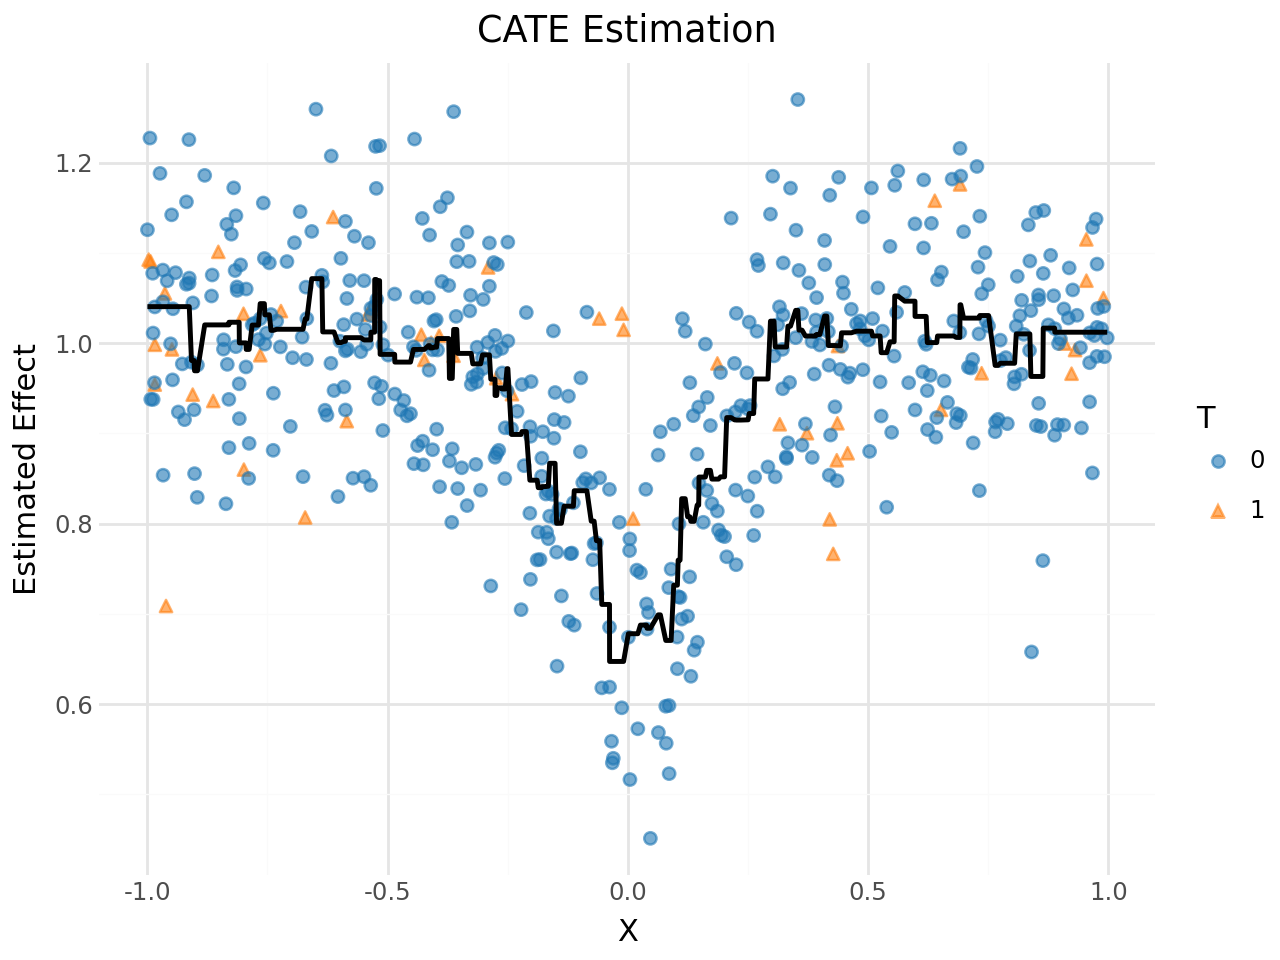

In [9]:
# ---------------------------------------------------------
# GRÁFICO 2: Efecto Estimado (CATE)
# ---------------------------------------------------------
(
    ggplot(df, aes(x="x"))
    # Scatter de efectos individuales estimados (tau)
    + geom_point(aes(y="tau_hat", color="t_factor", shape="t_factor"), alpha=0.6, size=2)
    # Línea del CATE (sobre todo el rango X)
    + geom_line(aes(y="cate_hat"), color="black", size=1)
    + labs(y="Estimated Effect", x="X", color="T", shape="T", title="CATE Estimation")
    + scale_color_manual(values=["#1f77b4", "#ff7f0e"])
    + theme_minimal()
)

## X-Learner

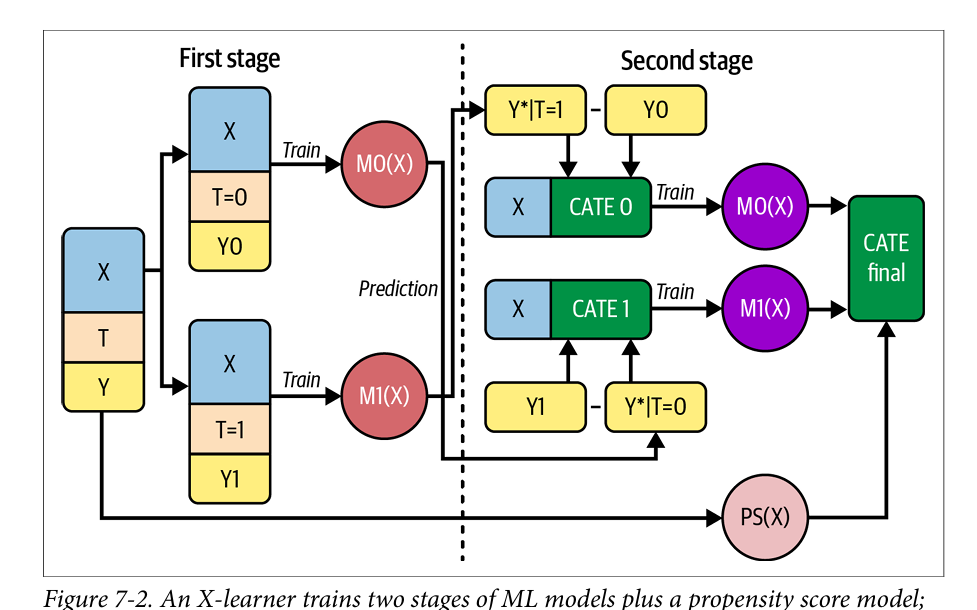

C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names


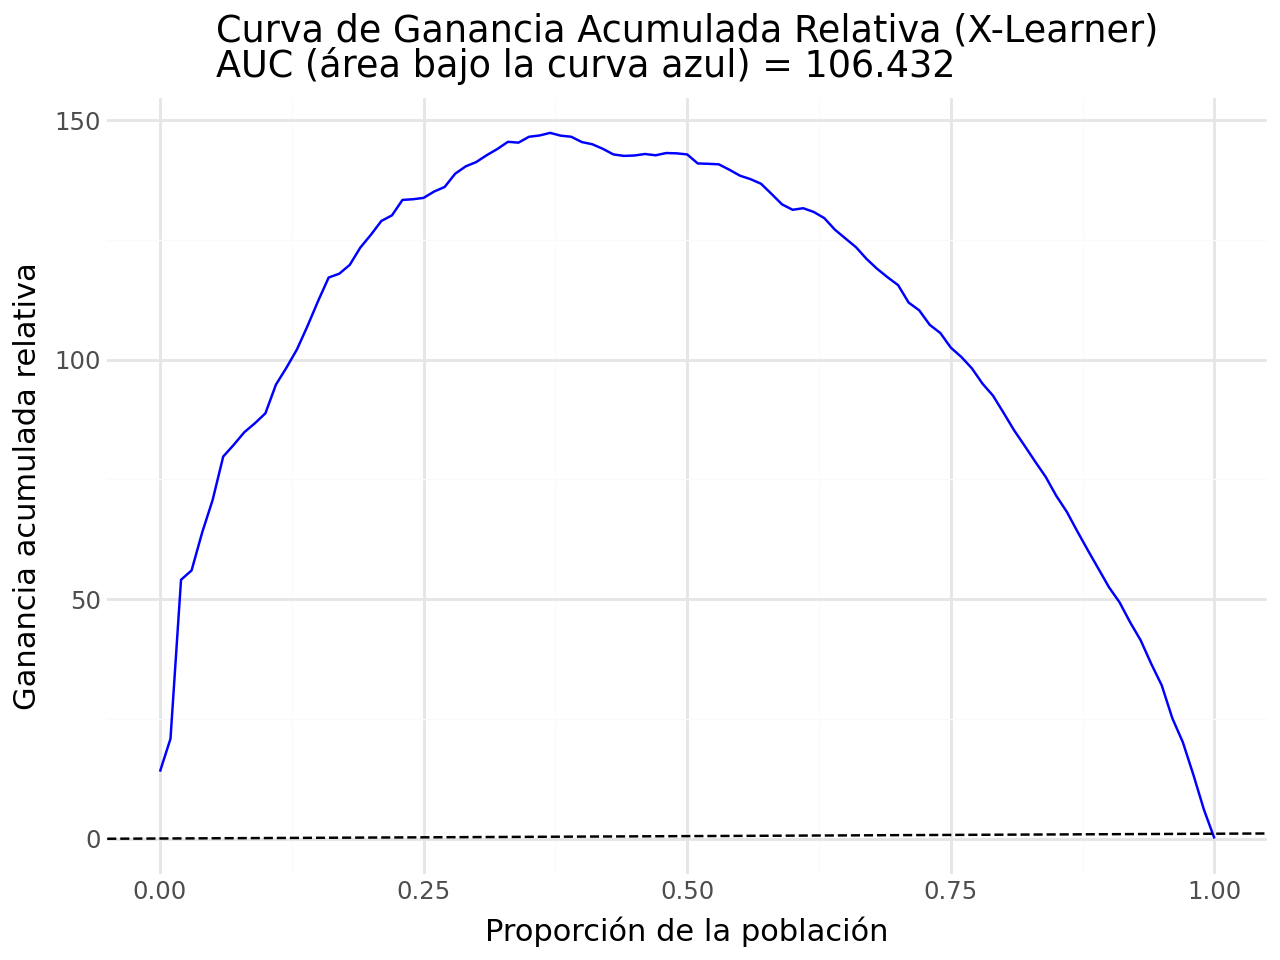

In [10]:
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMRegressor

# Propensity Score Model
ps_model = LogisticRegression(penalty=None)
ps_model.fit(
    train.select(X).to_numpy(), 
    train.select(T).to_numpy().ravel()
)

# first stage models
train_t0 = train.filter(pl.col(T) == 0)
train_t1 = train.filter(pl.col(T) == 1)

m0 = LGBMRegressor()
m1 = LGBMRegressor()

np.random.seed(123)

m0.fit(
    train_t0.select(X).to_numpy(), 
    train_t0.select(y).to_numpy().ravel(),
    sample_weight=1/ps_model.predict_proba(train_t0.select(X).to_numpy())[:, 0]
)

m1.fit(
    train_t1.select(X).to_numpy(), 
    train_t1.select(y).to_numpy().ravel(),
    sample_weight=1 / ps_model.predict_proba(train_t1.select(X).to_numpy())[:,1]
)

# Second Stage

tau_hat_0 = m1.predict(train_t0.select(X).to_numpy()) - train_t0.select(y).to_numpy().ravel()
tau_hat_1 = train_t1.select(y).to_numpy().ravel() - m0.predict(train_t1.select(X).to_numpy())

m_tau_0 = LGBMRegressor()
m_tau_1 = LGBMRegressor()

np.random.seed(123)

m_tau_0.fit(train_t0.select(X).to_numpy(), tau_hat_0)
m_tau_1.fit(train_t1.select(X).to_numpy(), tau_hat_1)

# Estimate CATE on test set
ps_test = ps_model.predict_proba(test.select(X).to_numpy())[:,1]

x_cate_test = test.with_columns(
    cate=pl.Series(
        ps_test * m_tau_1.predict(test.select(X).to_numpy()) + 
        (1 - ps_test) * m_tau_0.predict(test.select(X).to_numpy()
    )
))

gain_curve_test = relative_cumulative_gain_curve(x_cate_test.to_pandas(), T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(x_cate_test.to_pandas(), T, y, prediction="cate")
gain_curve_test = pl.DataFrame(gain_curve_test, schema=["gain"])
x = np.linspace(0, 1, len(gain_curve_test))

(
    ggplot(gain_curve_test) +
    geom_line(aes(x=x, y="gain"), color="blue") +  # Línea azul: curva de ganancia acumulada (AUC)
    geom_abline(slope=1, intercept=0, linetype="dashed") +  # Línea punteada: baseline (modelo aleatorio)
    labs(
        title=f"Curva de Ganancia Acumulada Relativa (X-Learner)\nAUC (área bajo la curva azul) = {auc:.3f}",
        x="Proporción de la población",
        y="Ganancia acumulada relativa"
    ) +
    theme_minimal()
)

## Metalearners for Continuous Treatments

In [11]:
data_cont = pl.read_csv("../data/discount_data.csv")
data_cont.head()

rest_id,day,month,weekday,weekend,is_holiday,is_dec,is_nov,competitors_price,discounts,sales
i64,str,i64,i64,bool,bool,bool,bool,f64,i64,f64
0,"""2016-01-01""",1,4,false,true,false,false,2.88,0,79.0
0,"""2016-01-02""",1,5,true,false,false,false,2.64,0,57.0
0,"""2016-01-03""",1,6,true,false,false,false,2.08,5,294.0
0,"""2016-01-04""",1,0,false,false,false,false,3.37,15,676.5
0,"""2016-01-05""",1,1,false,false,false,false,3.79,0,66.0


In [12]:
train = data_cont.filter(pl.col("day") <'2018-01-01')
test = data_cont.filter(pl.col("day") >= '2018-01-01')

## S-Learner

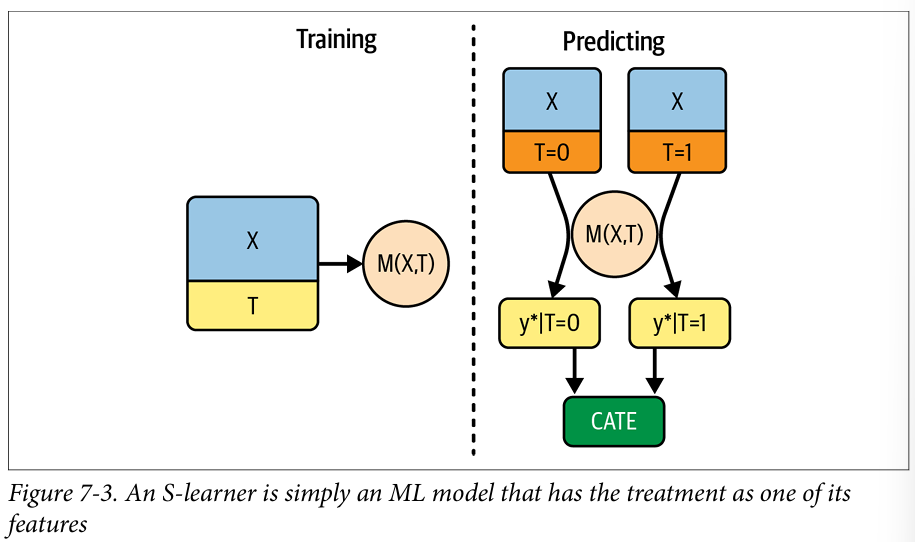

In [13]:
X = ["month", "weekday", "is_holiday", "competitors_price"]
T = "discounts"
y = "sales"

np.random.seed(123)
s_learner = LGBMRegressor()
s_learner.fit(
    train.select(X + [T]).to_numpy(), 
    train.select(y).to_numpy().ravel()
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [14]:
# 1. Crear el grid
t_grid = pl.DataFrame({
    "discounts": [0, 10, 20, 30, 40]
})

# 2. Operación corregida
test_cf = (
    test
    .drop("discounts")
    .join(t_grid, how="cross")
)

X_T_matrix = test_cf.select(X + [T]).to_numpy()
test_cf = test_cf.with_columns(
    sales_hat = pl.Series(s_learner.predict(X_T_matrix))
)

print(test_cf.head(8))

shape: (8, 12)
┌─────────┬────────────┬───────┬─────────┬───┬───────────────────┬───────┬───────────┬─────────────┐
│ rest_id ┆ day        ┆ month ┆ weekday ┆ … ┆ competitors_price ┆ sales ┆ discounts ┆ sales_hat   │
│ ---     ┆ ---        ┆ ---   ┆ ---     ┆   ┆ ---               ┆ ---   ┆ ---       ┆ ---         │
│ i64     ┆ str        ┆ i64   ┆ i64     ┆   ┆ f64               ┆ f64   ┆ i64       ┆ f64         │
╞═════════╪════════════╪═══════╪═════════╪═══╪═══════════════════╪═══════╪═══════════╪═════════════╡
│ 0       ┆ 2018-01-01 ┆ 1     ┆ 0       ┆ … ┆ 4.92              ┆ 251.5 ┆ 0         ┆ 67.957972   │
│ 0       ┆ 2018-01-01 ┆ 1     ┆ 0       ┆ … ┆ 4.92              ┆ 251.5 ┆ 10        ┆ 444.245941  │
│ 0       ┆ 2018-01-01 ┆ 1     ┆ 0       ┆ … ┆ 4.92              ┆ 251.5 ┆ 20        ┆ 793.045769  │
│ 0       ┆ 2018-01-01 ┆ 1     ┆ 0       ┆ … ┆ 4.92              ┆ 251.5 ┆ 30        ┆ 1279.640793 │
│ 0       ┆ 2018-01-01 ┆ 1     ┆ 0       ┆ … ┆ 4.92              ┆ 251.5 ┆ 4

C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names


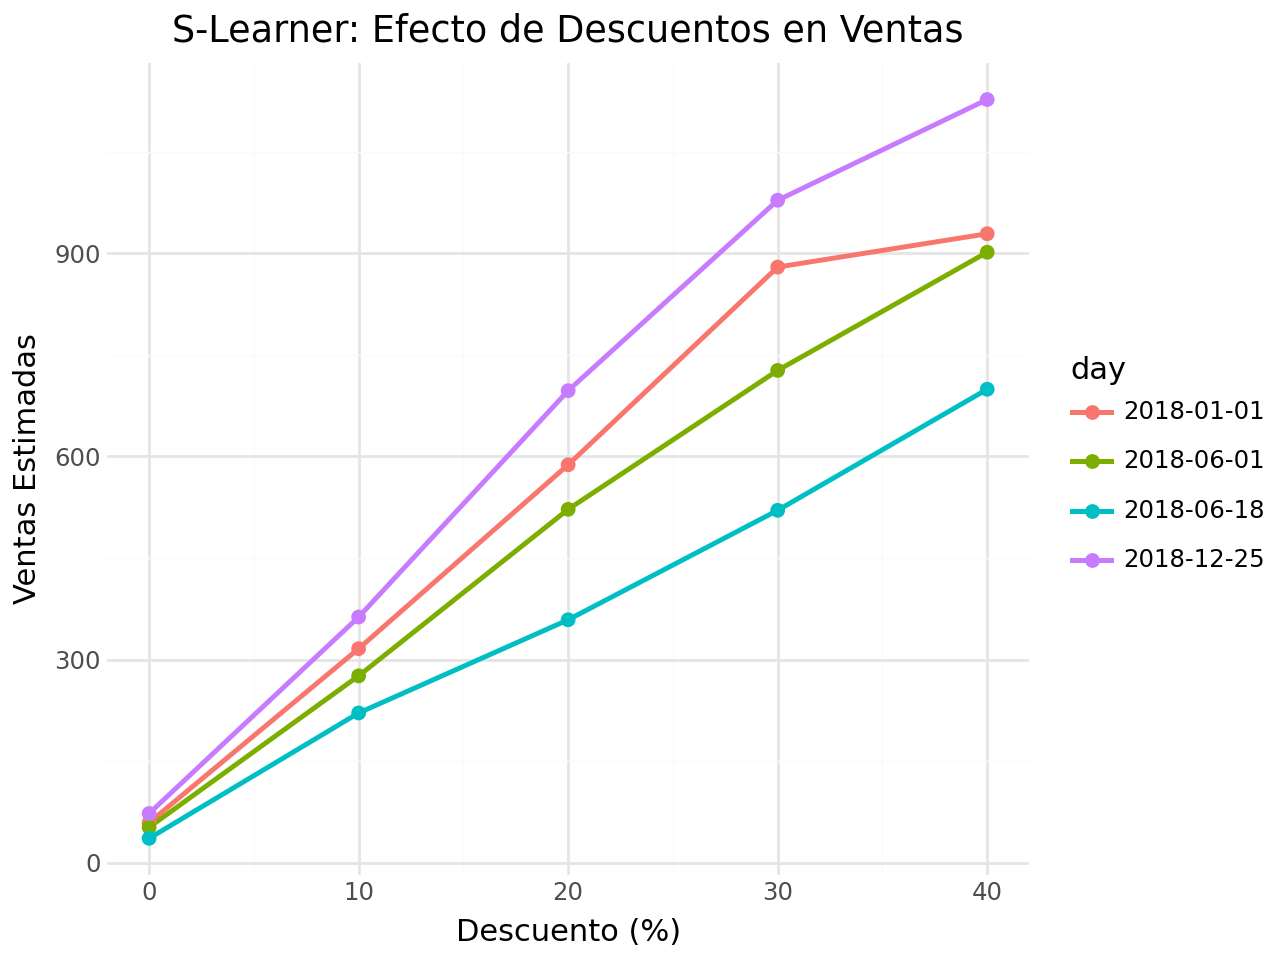

In [15]:
days = ["2018-12-25", "2018-01-01", "2018-06-01", "2018-06-18"]

plt_data = test_cf.filter(pl.col("day").is_in(days)).filter(pl.col("rest_id") == 2)

(
    ggplot(plt_data, aes(x="discounts", y="sales_hat", color="day")) +
    geom_line(size=1) +
    geom_point(size=2) +
    labs(
        title="S-Learner: Efecto de Descuentos en Ventas",
        x="Descuento (%)",
        y="Ventas Estimadas"
    ) +
    theme_minimal()
)

Para calcular la pendiente de la regresión lineal simple de manera eficiente, utilizamos la siguiente fórmula estadística:

$$
\beta = \frac{\operatorname{Cov}(t, y)}{\operatorname{Var}(t)}
$$

donde:

- $t$ representa el descuento aplicado,
- $y$ son las ventas predichas ($\widehat{\text{sales}}$).

Esta expresión nos da la sensibilidad estimada de las ventas respecto al descuento, es decir, el efecto causal marginal estimado del tratamiento continuo.

In [16]:
import polars as pl

# Calculamos la pendiente (CATE) directamente con expresiones de Polars
cate = test_cf.group_by(["rest_id", "day"]).agg(
    # Fórmula de la pendiente: Covarianza(Ventas, Descuento) / Varianza(Descuento)
    cate = pl.cov("sales_hat", "discounts") / pl.col("discounts").var()
)

# Unimos de vuelta al set de test original
test_s_learner_pred = test.join(cate, on=["rest_id", "day"], how="left")

print(test_s_learner_pred.head())

shape: (5, 12)
┌─────────┬────────────┬───────┬─────────┬───┬───────────────────┬───────────┬───────┬───────────┐
│ rest_id ┆ day        ┆ month ┆ weekday ┆ … ┆ competitors_price ┆ discounts ┆ sales ┆ cate      │
│ ---     ┆ ---        ┆ ---   ┆ ---     ┆   ┆ ---               ┆ ---       ┆ ---   ┆ ---       │
│ i64     ┆ str        ┆ i64   ┆ i64     ┆   ┆ f64               ┆ i64       ┆ f64   ┆ f64       │
╞═════════╪════════════╪═══════╪═════════╪═══╪═══════════════════╪═══════════╪═══════╪═══════════╡
│ 0       ┆ 2018-01-01 ┆ 1     ┆ 0       ┆ … ┆ 4.92              ┆ 5         ┆ 251.5 ┆ 37.247404 │
│ 0       ┆ 2018-01-02 ┆ 1     ┆ 1       ┆ … ┆ 3.06              ┆ 10        ┆ 541.0 ┆ 40.269854 │
│ 0       ┆ 2018-01-03 ┆ 1     ┆ 2       ┆ … ┆ 4.61              ┆ 10        ┆ 431.0 ┆ 37.412988 │
│ 0       ┆ 2018-01-04 ┆ 1     ┆ 3       ┆ … ┆ 4.84              ┆ 20        ┆ 760.0 ┆ 38.436815 │
│ 0       ┆ 2018-01-05 ┆ 1     ┆ 4       ┆ … ┆ 6.29              ┆ 0         ┆ 78.0  ┆ 31.4286

In [17]:
# Imprimir los días con mayor efecto estimado
top_days = test_s_learner_pred.sort("cate", descending=True).select(["rest_id", "day", "cate"]).head(10)
print(top_days)

shape: (10, 3)
┌─────────┬────────────┬───────────┐
│ rest_id ┆ day        ┆ cate      │
│ ---     ┆ ---        ┆ ---       │
│ i64     ┆ str        ┆ f64       │
╞═════════╪════════════╪═══════════╡
│ 1       ┆ 2018-10-19 ┆ 46.447882 │
│ 0       ┆ 2018-10-12 ┆ 46.369516 │
│ 0       ┆ 2018-09-07 ┆ 45.910056 │
│ 0       ┆ 2018-09-21 ┆ 45.807766 │
│ 4       ┆ 2018-10-05 ┆ 45.594792 │
│ 0       ┆ 2018-10-26 ┆ 45.405663 │
│ 5       ┆ 2018-10-12 ┆ 45.405663 │
│ 0       ┆ 2018-07-27 ┆ 44.962515 │
│ 3       ┆ 2018-07-27 ┆ 44.962515 │
│ 0       ┆ 2018-11-16 ┆ 44.876189 │
└─────────┴────────────┴───────────┘


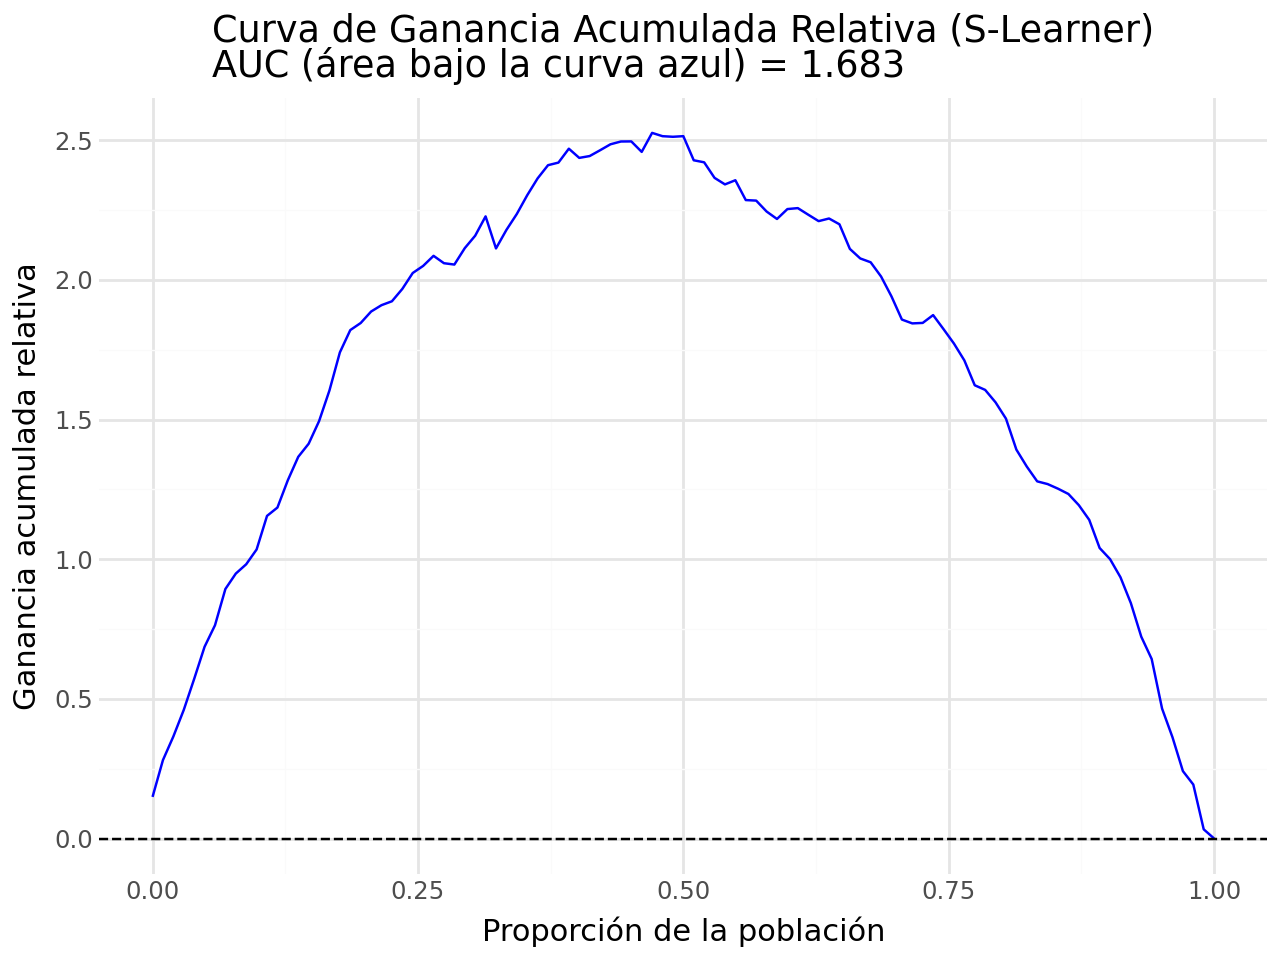

In [18]:
from fklearn.causal.validation.auc import area_under_the_relative_cumulative_gain_curve
from fklearn.causal.validation.curves import relative_cumulative_gain_curve

gain_curve_test = relative_cumulative_gain_curve(test_s_learner_pred.to_pandas(), T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(test_s_learner_pred.to_pandas(), T, y, prediction="cate")
gain_curve_test = pl.DataFrame(gain_curve_test, schema=["gain"])
x = np.linspace(0, 1, len(gain_curve_test))

(
    ggplot(gain_curve_test) +
    geom_line(aes(x=x, y="gain"), color="blue") +  # Línea azul: curva de ganancia acumulada (AUC)
    geom_abline(slope=0, intercept=0, linetype="dashed") +  # Línea punteada: baseline (modelo aleatorio)
    labs(
        title=f"Curva de Ganancia Acumulada Relativa (S-Learner)\nAUC (área bajo la curva azul) = {auc:.3f}",
        x="Proporción de la población",
        y="Ganancia acumulada relativa"
    ) +
    theme_minimal()
)

Tener cuidado con el bias que puede contener un S-learner, del sesgo hacia cero.

Regularmente el S-learner tiende a subestimar los efectos del tratamiento, acercándolos a cero. Esto ocurre porque el modelo intenta minimizar el error global, lo que puede llevar a que los efectos del tratamiento se diluyan en la predicción general. Es importante ser consciente de este sesgo al interpretar los resultados obtenidos con un S-learner y considerar técnicas adicionales para mitigar este efecto si es necesario.

## R-Learner or Double Machine Learning

In [19]:
from sklearn.model_selection import cross_val_predict
from lightgbm import LGBMRegressor

X = ["month", "weekday", "is_holiday", "competitors_price"]
T = "discounts"
y = "sales"
debias_m = LGBMRegressor()
denoise_m = LGBMRegressor()
t_res =  train.select(T).to_numpy().ravel() - cross_val_predict(debias_m,train.select(X).to_pandas(),train.select(T).to_pandas(),cv=5)
y_res =  train.select(y).to_numpy().ravel() - cross_val_predict(denoise_m,train.select(X).to_pandas(),train.select(y).to_pandas(),cv=5)


In [20]:
import statsmodels.api as sm
sm.OLS(y_res, t_res).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
x1,31.4634,0.151,209.017,0.000,31.168,31.759


In [21]:
y_star = y_res/t_res
w = t_res**2

cate_model = LGBMRegressor().fit(train.select(X).to_numpy(), y_star, sample_weight=w)

test_r_learner_pred = test.with_columns(cate = cate_model.predict(test.select(X).to_numpy()))

C:\Users\sergi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names


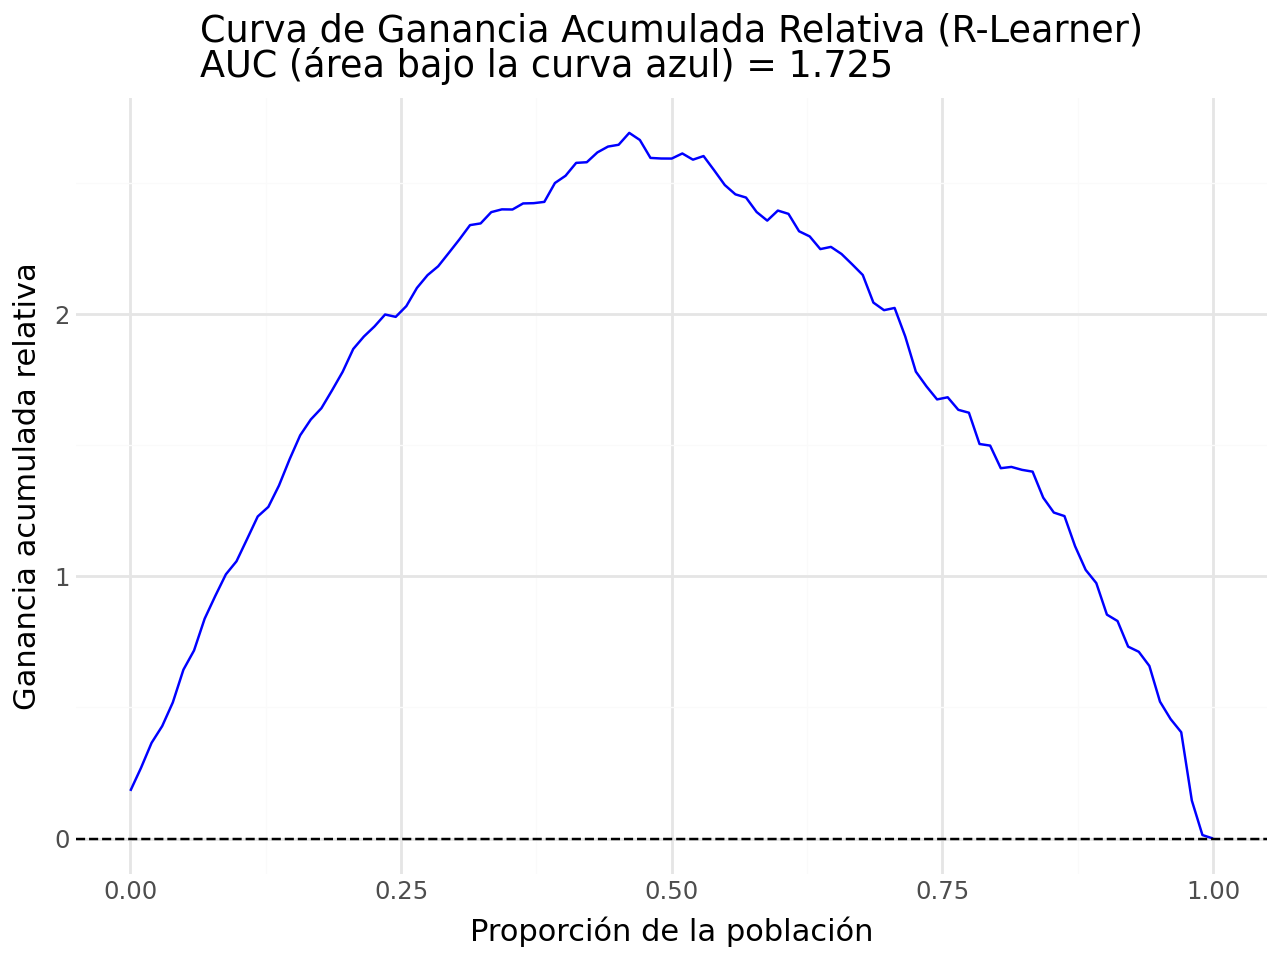

In [22]:
gain_curve_test = relative_cumulative_gain_curve(test_r_learner_pred.to_pandas(), T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(test_r_learner_pred.to_pandas(), T, y, prediction="cate")
gain_curve_test = pl.DataFrame(gain_curve_test, schema=["gain"])

x = np.linspace(0, 1, len(gain_curve_test))

(
    ggplot(gain_curve_test) +
    geom_line(aes(x=x, y="gain"), color="blue") +  # Línea azul: curva de ganancia acumulada (AUC)
    geom_abline(slope=0, intercept=0, linetype="dashed") +  # Línea punteada: baseline (modelo aleatorio)
    labs(
        title=f"Curva de Ganancia Acumulada Relativa (R-Learner)\nAUC (área bajo la curva azul) = {auc:.3f}",
        x="Proporción de la población",
        y="Ganancia acumulada relativa"
    ) +
    theme_minimal()
)

#### Visual Intuition for Double-ML


In [23]:
np.random.seed(123)
n = 5000

x_h = np.random.randint(1, 4, n)
x_c = np.random.uniform(-1, 1, n)

t = np.random.normal(10 + 1*x_c + 3*x_c**2 + x_c**3, 0.3)
y = np.random.normal(t + x_h*t - 5*x_c - x_c**2 - x_c**3, 0.3)

df_sim = pl.DataFrame(dict(x_h=x_h, x_c=x_c, t=t, y=y))
df_sim.head()

x_h,x_c,t,y
i32,f64,f64,f64
3,-0.764412,10.865583,47.599055
2,-0.003026,9.929159,29.740716
3,0.194219,9.768409,38.43642
3,-0.31849,9.875412,41.50537
1,0.422232,10.73371,19.116208


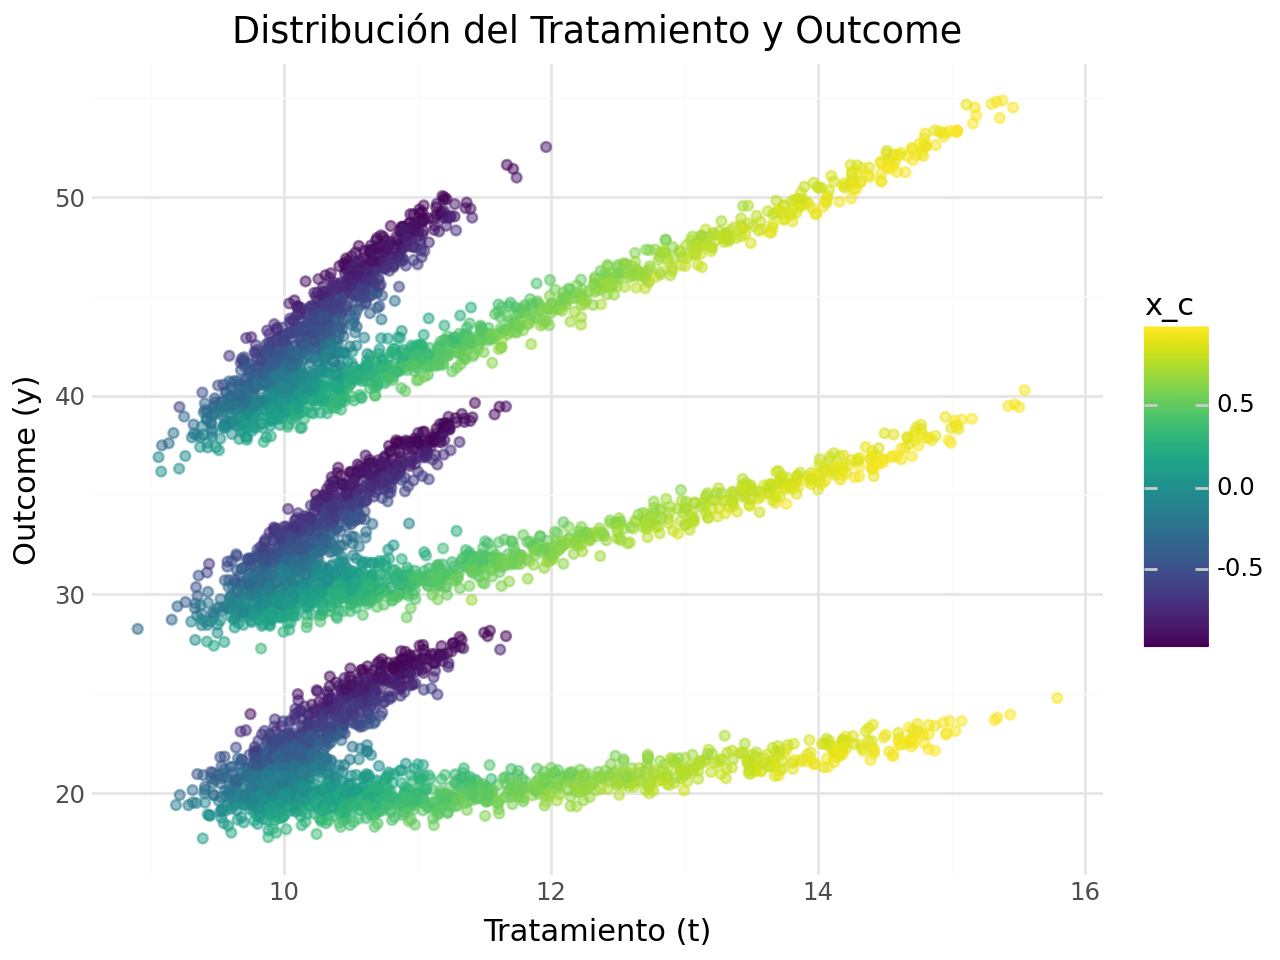

In [24]:
# Uso de plotnine para visualizar la distribución del tratamiento y el outcome en geom_point
(
    ggplot(df_sim, aes(x="t", y="y", color="x_c")) +
    geom_point(alpha=0.5) +
    labs(
        title="Distribución del Tratamiento y Outcome",
        x="Tratamiento (t)",
        y="Outcome (y)"
    ) +
    theme_minimal()
)

In [25]:
debias_m = LGBMRegressor(max_depth=3)
denoise_m = LGBMRegressor(max_depth=3)

t_res = cross_val_predict(debias_m,df_sim.select(["x_c"]).to_pandas(),df_sim.select("t").to_pandas(),cv=10)
y_res = cross_val_predict(denoise_m,df_sim.select(["x_c", "x_h"]).to_pandas(),df_sim.select("y").to_pandas(),cv=10)

df_res = df_sim.with_columns([
    pl.Series(df_sim.select("t").to_numpy().ravel() - t_res).alias("t_res"),
    pl.Series(df_sim.select("y").to_numpy().ravel() - y_res).alias("y_res")
])

df_res.head()

x_h,x_c,t,y,t_res,y_res
i32,f64,f64,f64,f64,f64
3,-0.764412,10.865583,47.599055,0.344975,1.841493
2,-0.003026,9.929159,29.740716,-0.063142,-0.546961
3,0.194219,9.768409,38.43642,-0.608929,-2.006162
3,-0.31849,9.875412,41.50537,-0.05139,0.369727
1,0.422232,10.73371,19.116208,-0.252611,-0.69982


In [26]:
import statsmodels.formula.api as smf
smf.ols("y_res ~ t_res", data=df_res.to_pandas()).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.0007,0.006,-0.111,0.911,-0.013,0.011
t_res,3.0452,0.020,152.436,0.000,3.006,3.084


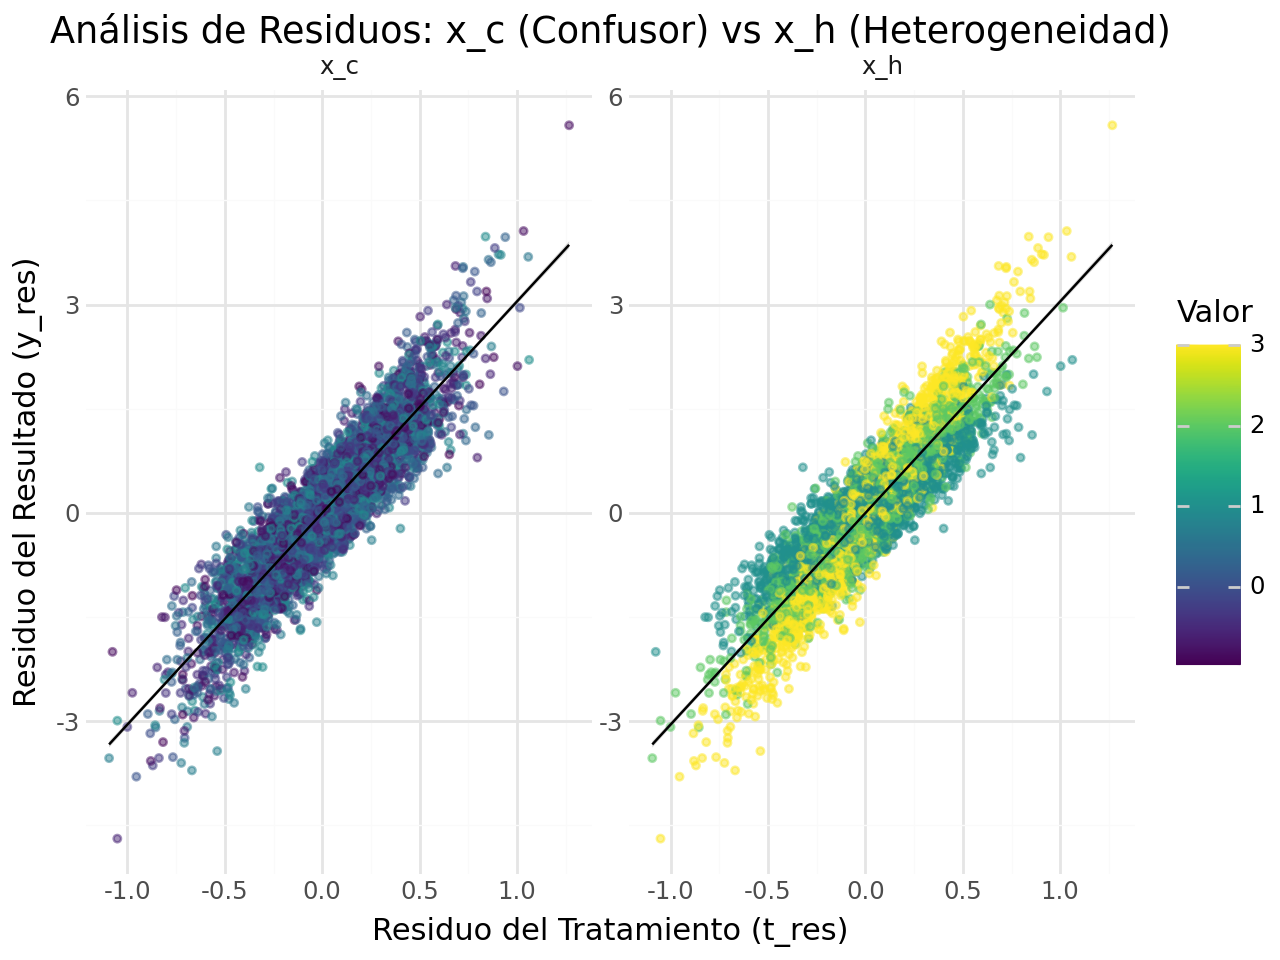

In [27]:
df_long = (
    df_res
    .with_columns(pl.col("x_h").cast(pl.Float64))
    .select(["t_res", "y_res", "x_c", "x_h"])
    .unpivot(index=["t_res", "y_res"], on=["x_c", "x_h"], variable_name="tipo_variable", value_name="valor_color")
)

# 2. Graficamos
(
    ggplot(df_long.to_pandas(), aes(x="t_res", y="y_res", color="valor_color")) +
    geom_point(alpha=0.5, size=1) +
    geom_smooth(method="lm", color="black", size=0.5) +
    # facet_wrap separa los dos gráficos: uno para x_c y otro para x_h
    facet_wrap("~tipo_variable", scales="free") + 
    scale_color_cmap(cmap_name="viridis") +
    labs(
        title="Análisis de Residuos: x_c (Confusor) vs x_h (Heterogeneidad)",
        x="Residuo del Tratamiento (t_res)",
        y="Residuo del Resultado (y_res)",
        color="Valor"
    ) +
    theme_minimal()
)

CATE Promedio por grupo:
shape: (3, 2)
┌─────────┬───────────┐
│ x_h_str ┆ cate_mean │
│ ---     ┆ ---       │
│ str     ┆ f64       │
╞═════════╪═══════════╡
│ 1       ┆ 2.01976   │
│ 2       ┆ 2.974968  │
│ 3       ┆ 3.996238  │
└─────────┴───────────┘


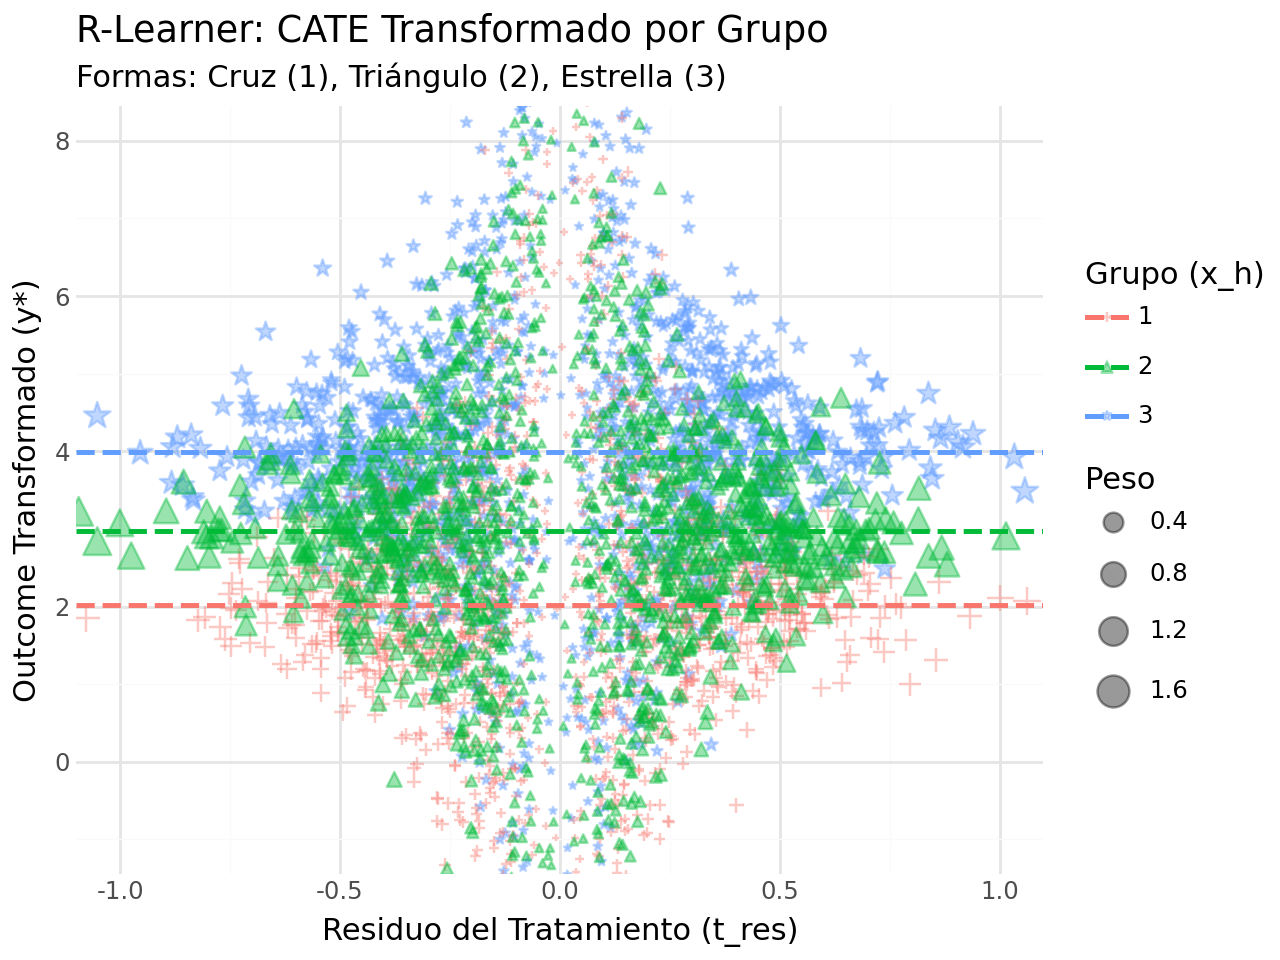

In [28]:

# 1. Preparación de datos (Calculamos y_star y weight)
# Convertimos x_h a string para que sea categórico
df_star = df_res.with_columns(
    y_star = pl.col("y_res") / pl.col("t_res"),
    weight = pl.col("t_res") ** 2,
    x_h_str = pl.col("x_h").cast(pl.Utf8) 
)

# 2. Calcular los promedios ponderados (CATE) para las líneas horizontales
cate_means = (
    df_star.group_by("x_h_str")
    .agg(
        cate_mean = (pl.col("y_star") * pl.col("weight")).sum() / pl.col("weight").sum()
    )
).sort("x_h_str") # Ordenamos para asegurar consistencia

print("CATE Promedio por grupo:")
print(cate_means)

# 3. Gráfico con formas personalizadas
(
    ggplot(df_star)
    # Definimos las estéticas globales
    + aes(x="t_res", y="y_star", color="x_h_str", shape="x_h_str")
    
    # Capa de Puntos
    + geom_point(aes(size="weight"), alpha=0.4)
    
    # --- AQUÍ ESTÁ LA PERSONALIZACIÓN DE FORMAS ---
    # Valores de matplotlib: '+' (cruz), '^' (triángulo), '*' (estrella)
    + scale_shape_manual(values=['+', '^', '*']) 
    # ----------------------------------------------

    # Capa de Líneas Horizontales (Promedios)
    + geom_hline(
        aes(yintercept="cate_mean", color="x_h_str"), 
        data=cate_means, 
        size=1, 
        linetype="dashed"
    )
    
    # Límites y Etiquetas
    + coord_cartesian(ylim=(-1, 8), xlim=(-1, 1))
    + labs(
        title="R-Learner: CATE Transformado por Grupo",
        subtitle="Formas: Cruz (1), Triángulo (2), Estrella (3)",
        x="Residuo del Tratamiento (t_res)",
        y="Outcome Transformado (y*)",
        color="Grupo (x_h)",
        shape="Grupo (x_h)",
        size="Peso"
    )
    + theme_minimal()
)

## Ideas Clave: Metalearners para la Estimación de Efectos Causales Heterogéneos (CATE)

- **Meta-learners:** Son métodos que reutilizan modelos de machine learning genéricos para estimar el efecto causal promedio condicional (CATE), es decir, cómo varía el efecto del tratamiento según las características de cada individuo o grupo.

- **T-Learner:** 
    - Entrena un modelo predictivo para cada nivel del tratamiento $T$.
    - El efecto estimado es $\tau_{X_i} = \mu_1(X_i) - \mu_0(X_i)$.
    - Funciona bien si hay suficientes datos para cada grupo de tratamiento. Si no, puede sufrir sesgo de regularización.

- **X-Learner:** 
    - Introduce un modelo de propensión para ponderar la importancia de cada modelo $\mu_t$.
    - Reduce el sesgo cuando hay desbalance en el número de observaciones por tratamiento.

- **S-Learner:** 
    - Incluye el tratamiento como una covariable más en el modelo: $E[Y|T, X]$.
    - Permite hacer predicciones contrafactuales para distintos valores de $T$ (tratamiento continuo).
    - La función respuesta individual se resume en una pendiente (sensibilidad marginal).

- **Double Machine Learning (R-Learner):**
    - Utiliza modelos ML para obtener residuos ortogonalizados del tratamiento y el outcome: $T - E[T|X]$ y $Y - E[Y|X]$.
    - Construye el objetivo $Y^* = Y_{\text{res}} / T_{\text{res}}$ y lo predice usando ML, ponderando por $T_{\text{res}}^2$.
    - Permite estimar CATE directamente, robusteciendo frente a confusión.

- **Supuesto Fundamental: No Confusión (Unconfoundedness)**
    - Todos estos métodos requieren que los confusores relevantes estén medidos en los datos.
    - Bajo este supuesto, podemos interpretar la derivada de la esperanza condicional como el efecto causal marginal:
        $$
        \frac{\partial}{\partial t} E[Y|T = t, X]
        $$
